In [1]:
# Import necessary libraries
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

In [2]:
# Cell 1: Load and process the data
# Set paths
master_plan_path = "MasterPlan.geojson"
buildings_path = "newdelhi/newdelhibuildings.geojson"

# Read the GeoJSON files
print("Reading master plan...")
master_plan = gpd.read_file(master_plan_path)
print(f"Master plan loaded with {len(master_plan)} zones.")

print("Reading buildings...")
buildings = gpd.read_file(buildings_path)
print(f"Buildings loaded with {len(buildings)} features.")

# Fix invalid geometries if needed
master_plan.geometry = master_plan.geometry.buffer(0)
buildings.geometry = buildings.geometry.buffer(0)

# Ensure both datasets have the same CRS
if master_plan.crs != buildings.crs:
    print(f"Converting CRS from {buildings.crs} to {master_plan.crs}")
    buildings = buildings.to_crs(master_plan.crs)

Reading master plan...
Master plan loaded with 1748 zones.
Reading buildings...
Buildings loaded with 262907 features.


In [3]:

# Cell 2: Perform the spatial join
print("Performing spatial join...")
# Try with 'within' predicate first
buildings_with_names = gpd.sjoin(buildings, master_plan[["NAME", "geometry"]], 
                               how="left", predicate="within")

# If many buildings don't have a zone name, try with 'intersects'
unnamed_count = buildings_with_names['NAME'].isna().sum()
if unnamed_count > 0.25 * len(buildings):  # If more than 25% don't have names
    print(f"Many buildings ({unnamed_count}) don't have zones. Trying with 'intersects'...")
    buildings_with_names = gpd.sjoin(buildings, master_plan[["NAME", "geometry"]], 
                                   how="left", predicate="intersects")

# Fill NaN values with "Unknown"
buildings_with_names["NAME"] = buildings_with_names["NAME"].fillna("Unknown")

# Remove index_right column that was added by the spatial join
if "index_right" in buildings_with_names.columns:
    buildings_with_names = buildings_with_names.drop(columns=["index_right"])

# Display the first few rows
print("\nSample of joined data:")
display(buildings_with_names.head())

Performing spatial join...
Many buildings (113698) don't have zones. Trying with 'intersects'...

Sample of joined data:


,abandoned,access,addr:block,addr:city,addr:city:ur,addr:country,addr:district,addr:full,addr:housename,addr:housename:hi,...,type,unisex,water,website,wetland,wheelchair,wikidata,wikipedia,geometry,NAME
0,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,"POLYGON ((77.19205 28.40691, 77.19219 28.40692...",Unknown
1,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,"POLYGON ((77.19251 28.40692, 77.19265 28.40694...",Unknown
2,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,"POLYGON ((77.19902 28.4258, 77.19915 28.42583,...",REGIONAL PARK
3,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,"POLYGON ((77.19902 28.42816, 77.19908 28.42813...",REGIONAL PARK
4,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,"POLYGON ((77.19911 28.4283, 77.1992 28.42828, ...",REGIONAL PARK


In [4]:

# Cell 3: Analyze the building statistics
# Get basic statistics
total_buildings = len(buildings_with_names)
print(f"\n--- BASIC STATISTICS ---")
print(f"Total number of buildings: {total_buildings}")

# Count buildings by zone
identified_count = sum(buildings_with_names["NAME"] != "Unknown")
unknown_count = sum(buildings_with_names["NAME"] == "Unknown")

print(f"Buildings with identified zones: {identified_count} ({identified_count/total_buildings:.2%})")
print(f"Buildings without zones (Unknown): {unknown_count} ({unknown_count/total_buildings:.2%})")

# Get statistics by zone name
print(f"\n--- BUILDINGS BY ZONE TYPE ---")
zone_counts = buildings_with_names["NAME"].value_counts()
for zone, count in zone_counts.items():
    print(f"{zone}: {count} buildings ({count/total_buildings:.2%})")

# Building area statistics (if available)
area_cols = [col for col in buildings_with_names.columns if "area" in col.lower()]
if area_cols:
    area_col = area_cols[0]
    print(f"\n--- BUILDING AREA STATISTICS ---")
    print(f"Column used: {area_col}")
    
    # Calculate statistics directly
    try:
        mean_area = buildings_with_names[area_col].mean()
        median_area = buildings_with_names[area_col].median()
        min_area = buildings_with_names[area_col].min()
        max_area = buildings_with_names[area_col].max()
        std_area = buildings_with_names[area_col].std()
        
        print(f"Mean area: {mean_area:.2f}")
        print(f"Median area: {median_area:.2f}")
        print(f"Min area: {min_area:.2f}")
        print(f"Max area: {max_area:.2f}")
        print(f"Standard deviation: {std_area:.2f}")
    except Exception as e:
        print(f"Error calculating area statistics: {e}")
        print("First 5 values in the area column:")
        print(buildings_with_names[area_col].head())
else:
    print("\nNo area columns found in the data.")
    print("Available columns:", list(buildings_with_names.columns))



--- BASIC STATISTICS ---
Total number of buildings: 263427
Buildings with identified zones: 150274 (57.05%)
Buildings without zones (Unknown): 113153 (42.95%)

--- BUILDINGS BY ZONE TYPE ---
Unknown: 113153 buildings (42.95%)
RESIDENTIAL AREA: 95115 buildings (36.11%)
URBANISABLE AREA: 30898 buildings (11.73%)
SPECIAL AREA: 6263 buildings (2.38%)
AGRICULTURE: 3848 buildings (1.46%)
GOVERNMENT LAND: 2806 buildings (1.07%)
COMMUNITY PARK: 2113 buildings (0.80%)
MANUFACTURING SERVICE AND REPAIR INDUSTRY: 2043 buildings (0.78%)
UNIVERSITY CENTRE: 1271 buildings (0.48%)
SPORTS CENTRE: 727 buildings (0.28%)
AIR CITY: 712 buildings (0.27%)
REGIONAL PARK: 674 buildings (0.26%)
WHOLE SALE: 551 buildings (0.21%)
PARLIAMENT HOUSE: 385 buildings (0.15%)
DISTRICT CENTRE: 355 buildings (0.13%)
FOREIGN MISSION: 344 buildings (0.13%)
COMMUNITY CENTRE: 344 buildings (0.13%)
PRESIDENT HOUSE: 290 buildings (0.11%)
CITY PARK: 279 buildings (0.11%)
HOSPITAL: 272 buildings (0.10%)
CULTURAL COMPLEX: 139 bui

Creating pie chart of buildings by zone type...


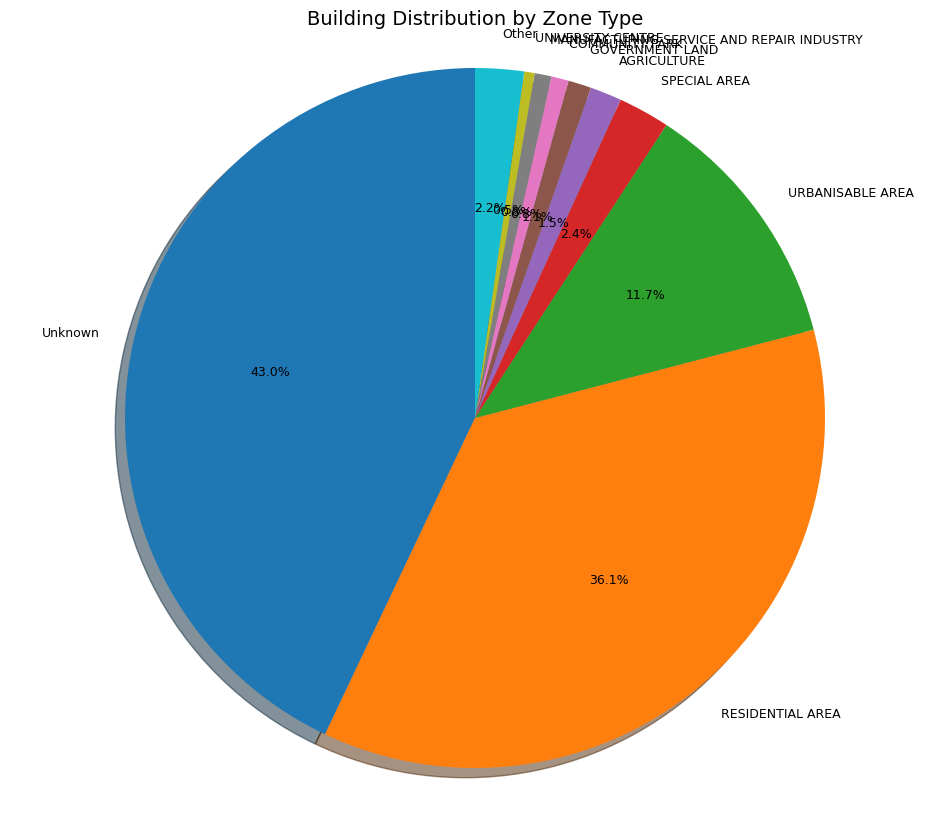

In [5]:
print("Creating pie chart of buildings by zone type...")

# If there are too many zones, group smaller ones as "Other"
if len(zone_counts) > 10:
    top_zones = zone_counts.head(9)
    other_count = zone_counts[9:].sum()
    plot_data = pd.Series({**top_zones.to_dict(), "Other": other_count})
else:
    plot_data = zone_counts

# Create the pie chart
plt.figure(figsize=(12, 10))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', 
        shadow=True, startangle=90, textprops={'fontsize': 9})
plt.axis('equal')
plt.title('Building Distribution by Zone Type', fontsize=14)
plt.show()


Creating bar chart of buildings by zone type...


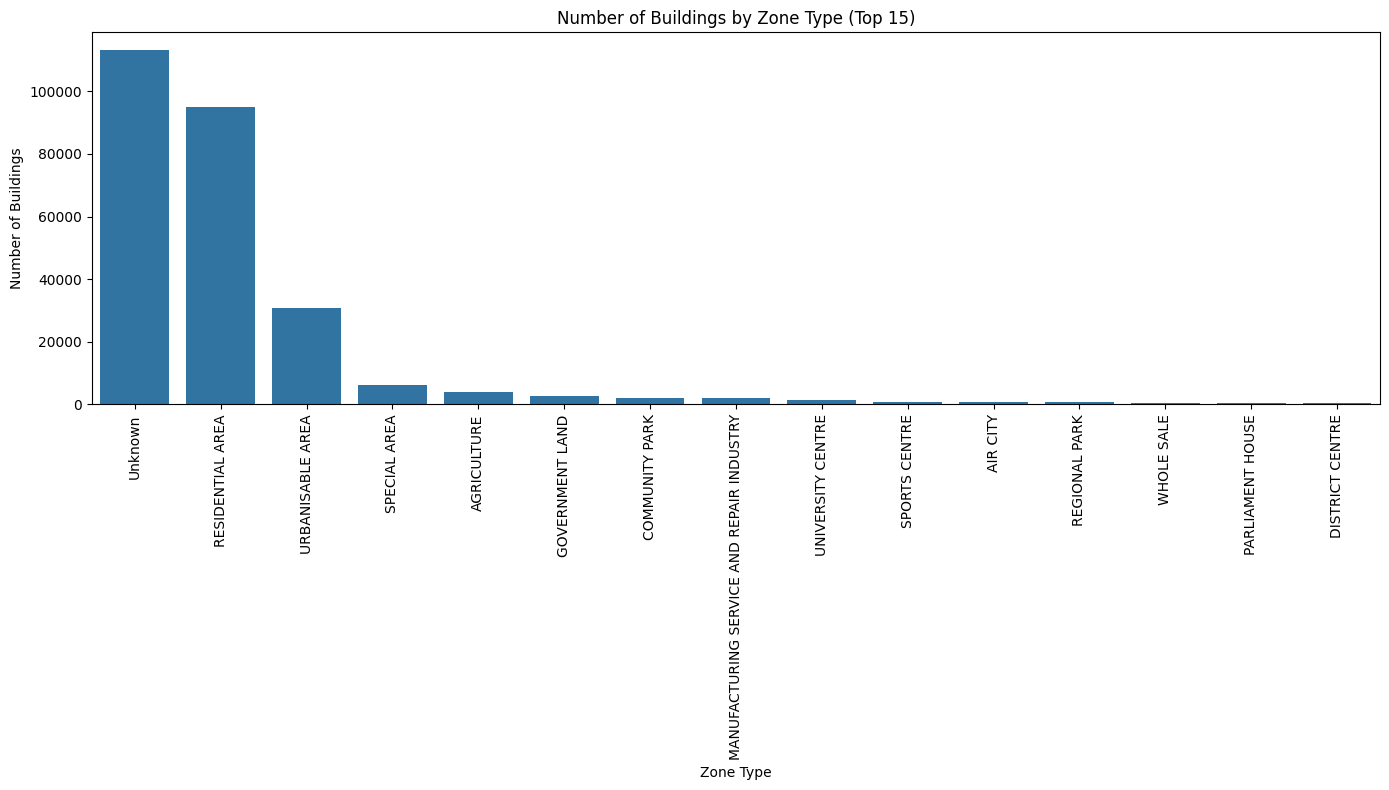

In [6]:
# Cell 5: Create bar chart of buildings by zone type
print("Creating bar chart of buildings by zone type...")

zone_counts = buildings_with_names["NAME"].value_counts().head(15)

plt.figure(figsize=(14, 8))
sns.barplot(x=zone_counts.index, y=zone_counts.values)
plt.title('Number of Buildings by Zone Type (Top 15)')
plt.xlabel('Zone Type')
plt.ylabel('Number of Buildings')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Creating map visualization of buildings by zone...


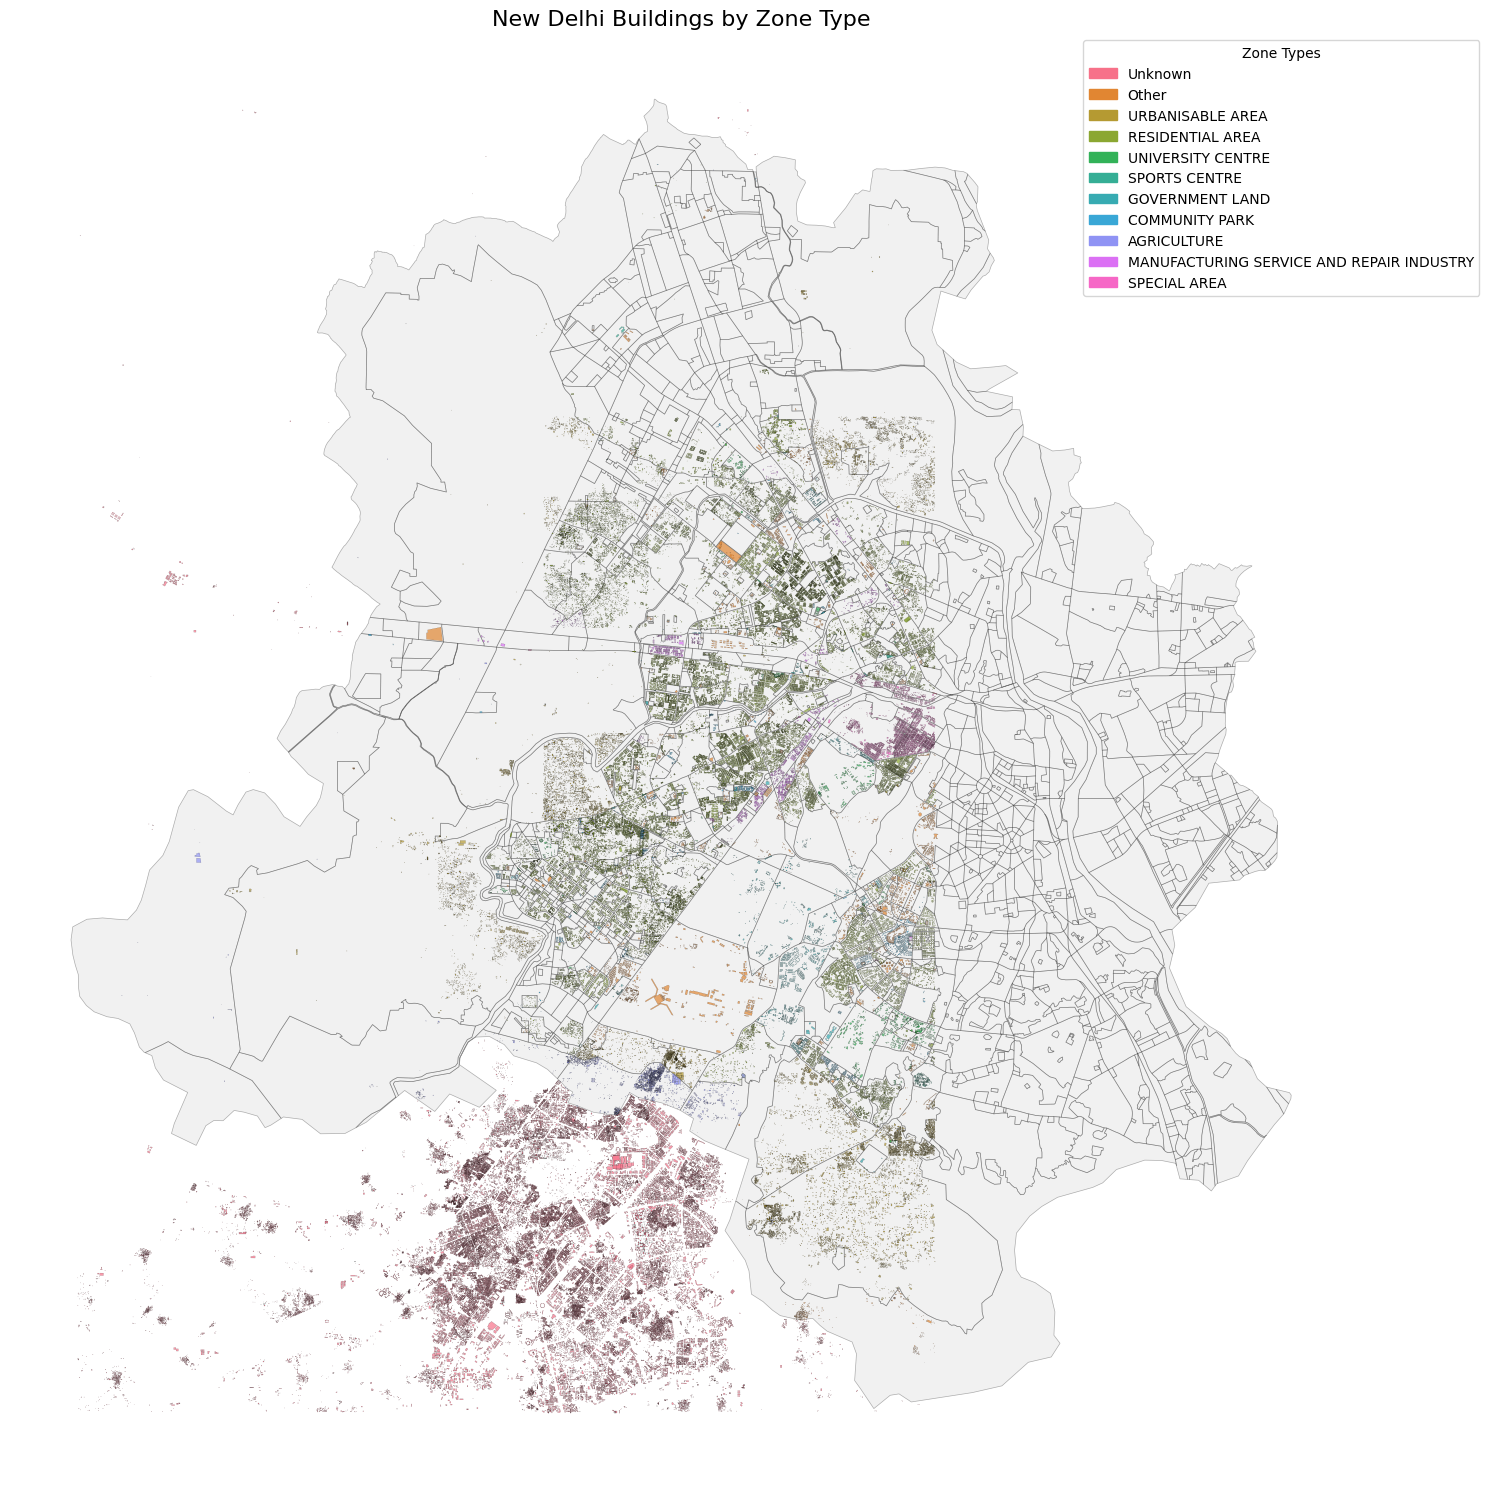

In [7]:

print("Creating map visualization of buildings by zone...")

# Get the top 10 zones by building count
top_zones = buildings_with_names["NAME"].value_counts().head(10).index.tolist()

# Create a 'zone_category' column
buildings_with_names['zone_category'] = buildings_with_names['NAME'].apply(
    lambda x: x if x in top_zones else 'Other'
)

# Create a categorical colormap
categories = buildings_with_names['zone_category'].unique()
n_categories = len(categories)

# Use a colorblind-friendly palette
colors = sns.color_palette("husl", n_categories)
cmap = ListedColormap(colors)

# Create the plot
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the master plan zones as background
try:
    master_plan.plot(ax=ax, alpha=0.3, edgecolor='black', linewidth=0.5, color='lightgrey')
except Exception as e:
    print(f"Warning: Could not plot master plan zones: {e}")

# Plot buildings colored by zone category
for i, category in enumerate(categories):
    try:
        category_buildings = buildings_with_names[buildings_with_names['zone_category'] == category]
        category_buildings.plot(
            ax=ax,
            color=colors[i],
            label=category,
            alpha=0.7,
            edgecolor='black',
            linewidth=0.1
        )
    except Exception as e:
        print(f"Warning: Could not plot buildings in category {category}: {e}")

# Create legend with patches
patches = [mpatches.Patch(color=colors[i], label=category) for i, category in enumerate(categories)]
plt.legend(handles=patches, loc='upper right', title="Zone Types", bbox_to_anchor=(1.1, 1))

plt.title("New Delhi Buildings by Zone Type", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Cell 7: Interactive Map Visualization with OpenStreetMap (Fixed)
# Install folium if not already installed
# !pip install folium

import folium
from folium.plugins import MarkerCluster, MiniMap, MeasureControl, Search
import branca.colormap as cm
import numpy as np

# Create an interactive map centered around New Delhi
# Get the centroid of all buildings for map centering
try:
    # Use union_all() instead of unary_union to avoid deprecation warning
    buildings_union = buildings_with_names.geometry.union_all()
    buildings_centroid = buildings_union.centroid
    map_center = [buildings_centroid.y, buildings_centroid.x]
except Exception as e:
    print(f"Error calculating centroid: {e}")
    # Fallback to simple average of coordinates
    valid_geoms = buildings_with_names[buildings_with_names.geometry.is_valid]
    if len(valid_geoms) > 0:
        sample_points = valid_geoms.geometry.representative_point()
        map_center = [sample_points.y.mean(), sample_points.x.mean()]
    else:
        # Default to a New Delhi coordinate
        print("Using default New Delhi coordinates")
        map_center = [28.6139, 77.2090]

# Create a base map with OpenStreetMap tiles
m = folium.Map(location=map_center, zoom_start=12, tiles='OpenStreetMap')

# Add additional base layers for the user to choose from with proper attribution
folium.TileLayer(
    'https://stamen-tiles-{s}.a.ssl.fastly.net/terrain/{z}/{x}/{y}.jpg',
    attr='Map tiles by <a href="http://stamen.com">Stamen Design</a>, under <a href="http://creativecommons.org/licenses/by/3.0">CC BY 3.0</a>. Data by <a href="http://openstreetmap.org">OpenStreetMap</a>, under <a href="http://www.openstreetmap.org/copyright">ODbL</a>.',
    name='Stamen Terrain',
).add_to(m)

folium.TileLayer(
    'https://stamen-tiles-{s}.a.ssl.fastly.net/toner/{z}/{x}/{y}.png',
    attr='Map tiles by <a href="http://stamen.com">Stamen Design</a>, under <a href="http://creativecommons.org/licenses/by/3.0">CC BY 3.0</a>. Data by <a href="http://openstreetmap.org">OpenStreetMap</a>, under <a href="http://www.openstreetmap.org/copyright">ODbL</a>.',
    name='Stamen Toner',
).add_to(m)

folium.TileLayer(
    'https://cartodb-basemaps-{s}.global.ssl.fastly.net/light_all/{z}/{x}/{y}.png',
    attr='&copy; <a href="http://www.openstreetmap.org/copyright">OpenStreetMap</a>, &copy; <a href="https://carto.com/attribution">CARTO</a>',
    name='CartoDB Positron',
).add_to(m)

folium.TileLayer(
    'https://cartodb-basemaps-{s}.global.ssl.fastly.net/dark_all/{z}/{x}/{y}.png',
    attr='&copy; <a href="http://www.openstreetmap.org/copyright">OpenStreetMap</a>, &copy; <a href="https://carto.com/attribution">CARTO</a>',
    name='CartoDB Dark Matter',
).add_to(m)

# Create a colormap for the zones
unique_zones = list(buildings_with_names['NAME'].unique())
# Remove 'Unknown' from the zones list if present
if 'Unknown' in unique_zones:
    unique_zones.remove('Unknown')
    
# Create a color map
n_zones = len(unique_zones)
color_map = cm.linear.Set1_09.scale(0, n_zones-1)
zone_colors = {zone: color_map(i) for i, zone in enumerate(unique_zones)}
# Add a specific color for unknown zones
zone_colors['Unknown'] = '#808080'  # Gray color for unknown zones

# Function to determine color based on zone
def get_color(zone):
    return zone_colors.get(zone, '#808080')  # Default to gray if not in dictionary

# Create a FeatureGroup for each zone type to allow toggling
zone_groups = {}
for zone in unique_zones + ['Unknown']:
    zone_groups[zone] = folium.FeatureGroup(name=zone)

# Add master plan zones as polygons with tooltips
for idx, row in master_plan.iterrows():
    try:
        zone_name = row['NAME']
        # Convert geometry to GeoJSON
        geo_json = folium.GeoJson(
            row['geometry'],
            style_function=lambda x, color=get_color(zone_name): {
                'fillColor': color,
                'color': 'black',
                'weight': 1,
                'fillOpacity': 0.2
            }
        )
        # Add a tooltip
        folium.Tooltip(f"Zone: {zone_name}").add_to(geo_json)
        # Add to the appropriate group
        if zone_name in zone_groups:
            geo_json.add_to(zone_groups[zone_name])
    except Exception as e:
        print(f"Error adding master plan zone {idx}: {e}")

# Sample buildings to improve performance (adjust N as needed)
N = 1000  # Number of buildings to sample
sampled_buildings = buildings_with_names.sample(min(N, len(buildings_with_names)))

# Add building polygons to the map
for idx, row in sampled_buildings.iterrows():
    try:
        zone = row['NAME']
        # Convert geometry to GeoJSON
        geo_json = folium.GeoJson(
            row['geometry'],
            style_function=lambda x, color=get_color(zone): {
                'fillColor': color,
                'color': 'black',
                'weight': 0.5,
                'fillOpacity': 0.7
            }
        )
        # Add a tooltip with info
        tooltip_text = f"Zone: {zone}"
        if 'area' in row:
            tooltip_text += f"<br>Area: {row['area']:.2f} sq m"
        folium.Tooltip(tooltip_text).add_to(geo_json)
        # Add to the appropriate group
        geo_json.add_to(zone_groups[zone])
    except Exception as e:
        print(f"Error adding building {idx}: {e}")

# Add all zone groups to the map
for zone, group in zone_groups.items():
    group.add_to(m)

# Add layer control to toggle zone visibility
folium.LayerControl().add_to(m)

# Add a colormap legend
color_map.caption = 'Zone Types'
m.add_child(color_map)

# Add a mini map for context
minimap = MiniMap()
m.add_child(minimap)

# Add a measure tool to calculate distances/areas
m.add_child(MeasureControl())

# Display the map
display(m)

Error adding building 248670: unsupported format string passed to NoneType.__format__
Error adding building 147679: unsupported format string passed to NoneType.__format__
Error adding building 230340: unsupported format string passed to NoneType.__format__
Error adding building 132309: unsupported format string passed to NoneType.__format__
Error adding building 84908: unsupported format string passed to NoneType.__format__
Error adding building 23989: unsupported format string passed to NoneType.__format__
Error adding building 130959: unsupported format string passed to NoneType.__format__
Error adding building 246272: unsupported format string passed to NoneType.__format__
Error adding building 5036: unsupported format string passed to NoneType.__format__
Error adding building 53788: unsupported format string passed to NoneType.__format__
Error adding building 205685: unsupported format string passed to NoneType.__format__
Error adding building 66598: unsupported format string pass

In [9]:
# Cell 10: Save the buildings with zone names to a new GeoJSON file
# After running the spatial join and analysis, use this to save the results

import os

# Define the output filename
output_filename = "newdelhi/newdelhibuildings_with_zones.geojson"

print(f"Saving buildings with zone names to: {output_filename}")

# Make sure the directory exists
os.makedirs(os.path.dirname(output_filename), exist_ok=True)

# Fix any invalid geometries before saving
buildings_to_save = buildings_with_names.copy()
invalid_count = sum(~buildings_to_save.geometry.is_valid)
if invalid_count > 0:
    print(f"Fixing {invalid_count} invalid geometries before saving...")
    buildings_to_save.geometry = buildings_to_save.geometry.buffer(0)
    
    # Check if fixes worked
    still_invalid = sum(~buildings_to_save.geometry.is_valid)
    if still_invalid > 0:
        print(f"Warning: {still_invalid} geometries are still invalid after attempted repair.")
        print("Removing invalid geometries to ensure valid GeoJSON output...")
        buildings_to_save = buildings_to_save[buildings_to_save.geometry.is_valid].copy()

try:
    # Save the GeoDataFrame to a new GeoJSON file
    buildings_to_save.to_file(output_filename, driver="GeoJSON")
    print(f"Successfully saved {len(buildings_to_save)} buildings to {output_filename}")
    
    # Display a sample of the saved data
    print("\nSample of the saved data:")
    display(buildings_to_save.head())
    
    # Get some statistics about the saved data
    identified_count = sum(buildings_to_save["NAME"] != "Unknown")
    total_buildings = len(buildings_to_save)
    
    print(f"\nSaved {total_buildings} buildings in total")
    print(f"Buildings with identified zones: {identified_count} ({identified_count/total_buildings:.2%})")
    print(f"Buildings without identified zones: {total_buildings - identified_count} ({(total_buildings - identified_count)/total_buildings:.2%})")
    
except Exception as e:
    print(f"Error saving file: {e}")
    
    # Try alternative approach if needed
    if "Failed to write feature" in str(e):
        print("Trying alternative approach with simplified geometries...")
        buildings_to_save.geometry = buildings_to_save.geometry.simplify(0.0001)
        buildings_to_save = buildings_to_save[buildings_to_save.geometry.is_valid].copy()
        buildings_to_save.to_file(output_filename, driver="GeoJSON")
        print(f"Successfully saved {len(buildings_to_save)} buildings with simplified geometries.")

Saving buildings with zone names to: newdelhi/newdelhibuildings_with_zones.geojson
Successfully saved 263427 buildings to newdelhi/newdelhibuildings_with_zones.geojson

Sample of the saved data:


,abandoned,access,addr:block,addr:city,addr:city:ur,addr:country,addr:district,addr:full,addr:housename,addr:housename:hi,...,unisex,water,website,wetland,wheelchair,wikidata,wikipedia,geometry,NAME,zone_category
0,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,"POLYGON ((77.19205 28.40691, 77.19219 28.40692...",Unknown,Unknown
1,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,"POLYGON ((77.19251 28.40692, 77.19265 28.40694...",Unknown,Unknown
2,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,"POLYGON ((77.19902 28.4258, 77.19915 28.42583,...",REGIONAL PARK,Other
3,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,"POLYGON ((77.19902 28.42816, 77.19908 28.42813...",REGIONAL PARK,Other
4,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,"POLYGON ((77.19911 28.4283, 77.1992 28.42828, ...",REGIONAL PARK,Other



Saved 263427 buildings in total
Buildings with identified zones: 150274 (57.05%)
Buildings without identified zones: 113153 (42.95%)


In [10]:
# Cell 11: Assign zone names to "Unknown" buildings based on statistics and features
# This version excludes the time-consuming proximity method
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.neighbors import KNeighborsClassifier
import random
from shapely.geometry import Point
import geopandas as gpd

# Create a copy of the buildings dataframe for the assignment
buildings_with_assigned = buildings_with_names.copy()

# Check how many buildings have unknown zones
unknown_buildings = buildings_with_assigned[buildings_with_assigned['NAME'] == 'Unknown']
known_buildings = buildings_with_assigned[buildings_with_assigned['NAME'] != 'Unknown']
print(f"Total buildings: {len(buildings_with_assigned)}")
print(f"Unknown zones: {len(unknown_buildings)} ({len(unknown_buildings)/len(buildings_with_assigned):.2%})")
print(f"Known zones: {len(known_buildings)} ({len(known_buildings)/len(buildings_with_assigned):.2%})")

# Get zone distribution for known buildings
zone_distribution = known_buildings['NAME'].value_counts(normalize=True)
print("\nZone distribution in known buildings:")
for zone, percentage in zone_distribution.items():
    print(f"{zone}: {percentage:.2%}")

print("\nChecking CRS of the dataset:")
print(f"CRS: {buildings_with_names.crs}")

# Helper function to reproject geometries for accurate calculations
def get_projected_gdf(gdf, target_crs="EPSG:32643"):
    """Project a GeoDataFrame to a projected CRS for accurate measurements"""
    if gdf.crs and gdf.crs.is_geographic:
        print(f"Reprojecting from {gdf.crs} to {target_crs} for accurate calculations")
        return gdf.to_crs(target_crs)
    return gdf

# Step 1: Calculate building features that might correlate with zone type
print("\nCalculating building features...")

def calculate_features(gdf):
    try:
        # Create a new dataframe for features
        features = pd.DataFrame(index=gdf.index)
        
        # Get a projected version for accurate measurements
        gdf_proj = get_projected_gdf(gdf)
        
        # Calculate area
        features['area'] = gdf_proj.geometry.area
        
        # Calculate perimeter
        features['perimeter'] = gdf_proj.geometry.length
        
        # Shape complexity (perimeter to area ratio)
        features['shape_complexity'] = features['perimeter'] / np.sqrt(features['area'])
        
        # Get centroids in projected space
        centroids = gdf_proj.geometry.centroid
        
        # Convert centroids back to original CRS if needed
        if gdf.crs and gdf.crs.is_geographic:
            centroid_points = gpd.GeoDataFrame(geometry=centroids, crs=gdf_proj.crs)
            centroid_points = centroid_points.to_crs(gdf.crs)
            features['x_coord'] = centroid_points.geometry.x
            features['y_coord'] = centroid_points.geometry.y
        else:
            features['x_coord'] = centroids.x
            features['y_coord'] = centroids.y
        
        return features
    
    except Exception as e:
        print(f"Error calculating features: {e}")
        # Return basic features as fallback
        features = pd.DataFrame(index=gdf.index)
        # Try to get reasonable coordinates at minimum
        try:
            points = gdf.geometry.representative_point()
            features['x_coord'] = points.x
            features['y_coord'] = points.y
        except:
            print("Could not calculate even basic coordinates")
            # Create dummy coordinates to avoid errors
            features['x_coord'] = 0
            features['y_coord'] = 0
        
        # Try to get area if possible
        try:
            if gdf.crs and gdf.crs.is_geographic:
                gdf_proj = gdf.to_crs("EPSG:32643")
                features['area'] = gdf_proj.geometry.area
            else:
                features['area'] = gdf.geometry.area
        except:
            features['area'] = 0
            
        return features

# Calculate features for known and unknown buildings
known_features = calculate_features(known_buildings)
unknown_features = calculate_features(unknown_buildings)

# Display feature statistics
print("\nFeature statistics for known buildings:")
print(known_features.describe())

# Method 1: K-Nearest Neighbors based on location and features
def assign_by_knn(known_buildings, known_features, unknown_buildings, unknown_features):
    print("\nAssigning zones using K-Nearest Neighbors...")
    
    # Select which features to use based on availability
    # Make sure to only use numeric features
    numeric_columns = [col for col in known_features.columns 
                      if pd.api.types.is_numeric_dtype(known_features[col])]
    
    available_features = [col for col in numeric_columns if col in unknown_features.columns]
    
    print(f"Using features for KNN: {available_features}")
    
    if not available_features:
        print("No usable features for KNN. Falling back to random assignment.")
        return assign_randomly(unknown_buildings, zone_distribution)
    
    # Handle missing values for each column separately
    known_features_clean = known_features[available_features].copy()
    unknown_features_clean = unknown_features[available_features].copy()
    
    for col in available_features:
        col_mean = known_features_clean[col].mean()
        known_features_clean[col] = known_features_clean[col].fillna(col_mean)
        unknown_features_clean[col] = unknown_features_clean[col].fillna(col_mean)
    
    # Standardize features
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(known_features_clean)
    X_test = scaler.transform(unknown_features_clean)
    
    # Train KNN model
    y_train = known_buildings['NAME'].values
    k = min(15, len(known_buildings))  # Choose k based on dataset size
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train, y_train)
    
    # Predict zones
    y_pred = knn.predict(X_test)
    
    # Get prediction probabilities
    y_proba = knn.predict_proba(X_test)
    
    # Create a dictionary with results
    results = {
        'predicted_zone': y_pred,
        'confidence': np.max(y_proba, axis=1)
    }
    
    return pd.DataFrame(results, index=unknown_buildings.index)

# Method 2: Statistical assignment based on area and zone probabilities
def assign_by_statistics(known_buildings, known_features, unknown_features):
    print("\nAssigning zones based on statistical patterns...")
    
    # Check if we have area information
    if 'area' not in known_features.columns or 'area' not in unknown_features.columns:
        print("Area information not available for statistical assignment")
        return assign_randomly(unknown_buildings, zone_distribution)
    
    # Calculate area distributions by zone
    area_stats = {}
    for zone, group in known_buildings.groupby('NAME'):
        if 'area' in known_features.columns:
            areas = known_features.loc[group.index, 'area']
            # Calculate mean and standard deviation
            area_stats[zone] = {
                'mean': areas.mean(),
                'std': areas.std() if areas.std() > 0 else areas.mean() * 0.1  # Avoid zero std
            }
    
    # Assign zones based on area likelihood and prior probability
    results = {'predicted_zone': [], 'probability': []}
    
    for idx, row in unknown_features.iterrows():
        if np.isnan(row['area']):
            # If area is unknown, use zone distribution
            zone_probs = zone_distribution.to_dict()
        else:
            # Calculate probability of each zone given the area
            zone_probs = {}
            for zone, stats in area_stats.items():
                # Probability from normal distribution
                try:
                    # Calculate probability density using normal distribution
                    from scipy.stats import norm
                    likelihood = norm.pdf(row['area'], 
                                          loc=stats['mean'], 
                                          scale=stats['std'])
                except:
                    # Fallback to simpler method
                    likelihood = 1 / (1 + abs(row['area'] - stats['mean']) / stats['std'])
                
                # Combine with prior probability (zone distribution)
                zone_probs[zone] = likelihood * zone_distribution[zone]
            
            # Normalize probabilities
            total = sum(zone_probs.values())
            if total > 0:
                zone_probs = {zone: prob/total for zone, prob in zone_probs.items()}
            else:
                zone_probs = zone_distribution.to_dict()
        
        # Choose zone with highest probability
        if len(zone_probs) > 0:
            predicted_zone = max(zone_probs.items(), key=lambda x: x[1])[0]
            probability = zone_probs[predicted_zone]
        else:
            predicted_zone = zone_distribution.index[0]
            probability = 1.0
            
        results['predicted_zone'].append(predicted_zone)
        results['probability'].append(probability)
    
    return pd.DataFrame(results, index=unknown_buildings.index)

# Method 3: Random assignment based on zone distribution
def assign_randomly(unknown_buildings, zone_distribution):
    print("\nAssigning zones randomly based on distribution...")
    
    zones = list(zone_distribution.index)
    probabilities = list(zone_distribution.values)
    
    # Generate random assignments
    random_zones = np.random.choice(zones, size=len(unknown_buildings), p=probabilities)
    
    # Create results dataframe
    results = {
        'predicted_zone': random_zones,
        'confidence': [0.5] * len(unknown_buildings)  # Add confidence column for consistency
    }
    
    return pd.DataFrame(results, index=unknown_buildings.index)

# Apply methods with proper error handling
print("\nApplying zone assignment methods...")

try:
    knn_results = assign_by_knn(known_buildings, known_features, unknown_buildings, unknown_features)
except Exception as e:
    print(f"Error in KNN assignment: {e}")
    # Create dummy results
    knn_results = pd.DataFrame({
        'predicted_zone': [zone_distribution.index[0]] * len(unknown_buildings),
        'confidence': [0.5] * len(unknown_buildings)
    }, index=unknown_buildings.index)

try:
    stats_results = assign_by_statistics(known_buildings, known_features, unknown_features)
except Exception as e:
    print(f"Error in statistical assignment: {e}")
    # Create dummy results
    stats_results = pd.DataFrame({
        'predicted_zone': [zone_distribution.index[0]] * len(unknown_buildings),
        'probability': [0.5] * len(unknown_buildings)
    }, index=unknown_buildings.index)

random_results = assign_randomly(unknown_buildings, zone_distribution)

# Step 3: Combine results with a weighted ensemble approach
print("\nCombining results with ensemble approach...")

# Make sure confidence column exists in all results
if 'confidence' not in knn_results.columns:
    knn_results['confidence'] = 0.5
if 'probability' in stats_results.columns and 'confidence' not in stats_results.columns:
    stats_results['confidence'] = stats_results['probability']
elif 'confidence' not in stats_results.columns:
    stats_results['confidence'] = 0.5

# Create ensemble weights (adjusted for no proximity method)
weights = {
    'knn': 0.6,          # K-nearest neighbors has highest weight
    'statistics': 0.3,    # Statistical patterns have medium weight
    'random': 0.1         # Random assignment has lowest weight
}

# Combine predictions
final_results = pd.DataFrame(index=unknown_buildings.index)

for idx in unknown_buildings.index:
    # Get predictions from each method
    predictions = {
        'knn': (knn_results.loc[idx, 'predicted_zone'], knn_results.loc[idx, 'confidence'] * weights['knn']),
        'statistics': (stats_results.loc[idx, 'predicted_zone'], stats_results.loc[idx, 'confidence'] * weights['statistics']),
        'random': (random_results.loc[idx, 'predicted_zone'], random_results.loc[idx, 'confidence'] * weights['random'])
    }
    
    # Count votes for each zone
    zone_votes = {}
    for method, (zone, weight) in predictions.items():
        if zone in zone_votes:
            zone_votes[zone] += weight
        else:
            zone_votes[zone] = weight
    
    # Select zone with highest vote
    if zone_votes:
        final_zone = max(zone_votes.items(), key=lambda x: x[1])[0]
        final_confidence = zone_votes[final_zone] / sum(zone_votes.values())
    else:
        # Fallback to most common zone
        final_zone = zone_distribution.index[0]
        final_confidence = 0.5
    
    final_results.loc[idx, 'predicted_zone'] = final_zone
    final_results.loc[idx, 'confidence'] = final_confidence

# Step 4: Apply the predictions to the original dataframe
print("\nApplying predictions to the buildings dataset...")

# Update the zone names in the buildings dataframe
for idx, row in final_results.iterrows():
    buildings_with_assigned.loc[idx, 'NAME'] = row['predicted_zone']
    # Add a column to indicate if the zone was assigned
    buildings_with_assigned.loc[idx, 'ZONE_ASSIGNED'] = True
    buildings_with_assigned.loc[idx, 'ASSIGNMENT_CONFIDENCE'] = row['confidence']

# Mark originally known zones
buildings_with_assigned.loc[known_buildings.index, 'ZONE_ASSIGNED'] = False

# Print statistics on assigned zones
assigned_zones = buildings_with_assigned.loc[unknown_buildings.index, 'NAME'].value_counts()
print("\nDistribution of assigned zones:")
for zone, count in assigned_zones.items():
    print(f"{zone}: {count} buildings ({count/len(unknown_buildings):.2%})")

# Print overall statistics
new_zone_distribution = buildings_with_assigned['NAME'].value_counts(normalize=True)
print("\nNew overall zone distribution after assignment:")
for zone, percentage in new_zone_distribution.items():
    print(f"{zone}: {percentage:.2%}")

# Save the resulting dataset
output_filename = "newdelhi/newdelhibuildings_complete_zones.geojson"
print(f"\nSaving complete buildings dataset with assigned zones to: {output_filename}")

try:
    # Ensure valid geometries
    buildings_with_assigned.geometry = buildings_with_assigned.geometry.buffer(0)
    buildings_with_assigned = buildings_with_assigned[buildings_with_assigned.geometry.is_valid].copy()
    # Save to file
    buildings_with_assigned.to_file(output_filename, driver="GeoJSON")
    print(f"Successfully saved {len(buildings_with_assigned)} buildings to {output_filename}")
except Exception as e:
    print(f"Error saving file: {e}")

# Return the updated dataframe for further use
display(buildings_with_assigned.head())

# Return success message
print("\nZone assignment complete!")

Total buildings: 263427
Unknown zones: 113153 (42.95%)
Known zones: 150274 (57.05%)

Zone distribution in known buildings:
RESIDENTIAL AREA: 63.29%
URBANISABLE AREA: 20.56%
SPECIAL AREA: 4.17%
AGRICULTURE: 2.56%
GOVERNMENT LAND: 1.87%
COMMUNITY PARK: 1.41%
MANUFACTURING SERVICE AND REPAIR INDUSTRY: 1.36%
UNIVERSITY CENTRE: 0.85%
SPORTS CENTRE: 0.48%
AIR CITY: 0.47%
REGIONAL PARK: 0.45%
WHOLE SALE: 0.37%
PARLIAMENT HOUSE: 0.26%
DISTRICT CENTRE: 0.24%
FOREIGN MISSION: 0.23%
COMMUNITY CENTRE: 0.23%
PRESIDENT HOUSE: 0.19%
CITY PARK: 0.19%
HOSPITAL: 0.18%
CULTURAL COMPLEX: 0.09%
INDUSTRY: 0.09%
RELIGIOUS: 0.08%
ELECTRICITY (POWER HOUSE SUB STATION): 0.07%
GENERAL BUSINESS: 0.07%
COLD STORAGE: 0.07%
POLICE HEADQUATER: 0.04%
SOCIAL CULTURAL: 0.03%
HOTEL: 0.03%
SEWERAGE (TREATMENT PLANT): 0.02%
EDUCATION AND RESEARCH: 0.02%
POLICE: 0.02%
HISTORICAL MONUMENTS: 0.01%
PARK: 0.01%
WAREHOUSING: 0.01%
WASTE LAND: 0.00%
WATER BODIES: 0.00%
SOLID WASTE (SANITERY LANDFILL): 0.00%
STADIUM: 0.00%
TRANSMI

,abandoned,access,addr:block,addr:city,addr:city:ur,addr:country,addr:district,addr:full,addr:housename,addr:housename:hi,...,website,wetland,wheelchair,wikidata,wikipedia,geometry,NAME,zone_category,ZONE_ASSIGNED,ASSIGNMENT_CONFIDENCE
0,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,"POLYGON ((77.19205 28.40691, 77.19219 28.40692...",REGIONAL PARK,Unknown,True,0.705607
1,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,"POLYGON ((77.19251 28.40692, 77.19265 28.40694...",REGIONAL PARK,Unknown,True,0.705307
2,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,"POLYGON ((77.19902 28.4258, 77.19915 28.42583,...",REGIONAL PARK,Other,False,NaN
3,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,"POLYGON ((77.19902 28.42816, 77.19908 28.42813...",REGIONAL PARK,Other,False,NaN
4,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,"POLYGON ((77.19911 28.4283, 77.1992 28.42828, ...",REGIONAL PARK,Other,False,NaN



Zone assignment complete!
